In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy
import copy

from scipy.sparse import coo_matrix, block_diag, identity, hstack, csr_matrix, csc_matrix, vstack
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import time 
import matplotlib as mpl

from pyiga import assemble, bspline, vform, geometry, vis, solvers, utils, topology, ieti, algebra, operators, adaptive
from pyiga import algebra_cy, ieti_cy, bspline_cy

from scipy.sparse.linalg import aslinearoperator as LinOp

np.set_printoptions(linewidth=100000)
np.set_printoptions(precision=5)

In [2]:
def admissibility_split(MP, a, return_P=False, subspace=False, consistency = True, with_edges=False):
    level={1:5, 2:5, 3:5, 4:5, 5:5, 6:5, 7:5}
    marked = set()
    mapped = lambda x: 1 if x in (0, 1) else 0
    num_split=0
    assert isinstance(a,dict) and len(a)==len(MP.mesh.domains), 'Invalid type for diffusion coefficient'
    if return_P:
        P = scipy.sparse.identity(MP.nLocDofs)
    while True:
        for p in range(MP.mesh.numpatches):
            for b in range(4):
                kv = MP.mesh.kvs[p][mapped(b)]
                deg = kv.p
                s1,s2 = kv.support()
                nodes = np.clip(MP.mesh.boundaries(p)[1][b],kv.kv[0],kv.kv[-1])
                m = min(nodes[1:]-nodes[:-1])
                if not bspline_cy.pyx_checkSWcondition(kv.kv, kv.p, len(kv.kv), nodes, len(nodes), with_edges) or (s2-s1)/m>2**level[deg]-1:
                    marked.add(p)
        if consistency:
            for (p1,b1) in MP.mesh.L_intfs:
                if len(MP.mesh.L_intfs[(p1,b1)])>1:
                    p2 = MP.mesh.L_intfs[(p1,b1)][0][0]
                    if a[MP.mesh.patch_domains[p1]] + 1e-3 < a[MP.mesh.patch_domains[p2]]:
                        marked.add(p1)
        if len(marked)>0:
            num_split+=len(marked)
            if return_P:
                P = MP.h_refine({p:None for p in marked}, ref="rs", return_P=return_P, in_subspace=subspace) @ P
            else:
                MP.h_refine({p:None for p in marked}, ref="rs", return_P=return_P, in_subspace=subspace)
            marked=set()
        else:
            break
    if consistency:
        print("Split {} additional patches due to admissibility and consistency".format(num_split))
    else:
        print("Split {} additional patches due to admissibility".format(num_split))
    if return_P:
        return P

In [3]:
def Inductor(deg,N, airgap=0.025):
    kvs=42*[2*(bspline.make_knots(deg,0.0,1.0,N),)]
    
    geos=[      
        geometry.unit_square().scale((0.5)).translate((-0.5,-0.5)),
        geometry.unit_square().scale((0.25,0.5)).translate((0,-0.5)),
        geometry.unit_square().scale((0.25,0.5)).translate((0.25,-0.5)),
        geometry.unit_square().scale((0.5,0.5)).translate((0.5,-0.5)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.,-0.5)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.25,-0.5)),
        geometry.unit_square().scale(0.5).translate((1.5,-0.5)),
        
        geometry.unit_square().scale((0.5,0.25)).translate((-0.5,0)),
        geometry.unit_square().scale(0.25),
        geometry.unit_square().scale(0.25).translate((0.25,0)),
        geometry.unit_square().scale((0.5,0.25)).translate((0.5,0)),
        geometry.unit_square().scale((0.25,0.25)).translate((1.,0)),
        geometry.unit_square().scale((0.25,0.25)).translate((1.25,0)),
        geometry.unit_square().scale((0.5,0.25)).translate((1.5,0)),
        
        geometry.unit_square().scale((0.5,airgap)).translate((-0.5,0.25)),
        geometry.unit_square().scale((0.25,airgap)).translate((0,0.25)),
        geometry.unit_square().scale((0.25,airgap)).translate((0.25,0.25)),
        geometry.unit_square().scale((0.5,airgap)).translate((0.5,0.25)),
        geometry.unit_square().scale((0.25,airgap)).translate((1.,0.25)),
        geometry.unit_square().scale((0.25,airgap)).translate((1.25,0.25)),
        geometry.unit_square().scale((0.5,airgap)).translate((1.5,0.25)),
        
        geometry.unit_square().scale((0.5,0.5)).translate((-0.5,0.25+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((0,0.25+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((0.25,0.25+airgap)),
        geometry.unit_square().scale((0.5,0.5)).translate((0.5,0.25+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.,0.25+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.25,0.25+airgap)),
        geometry.unit_square().scale((0.5,0.5)).translate((1.5,0.25+airgap)),
        
        geometry.unit_square().scale((0.5,0.25)).translate((-0.5,0.75+airgap)),
        geometry.unit_square().scale((0.25,0.25)).translate((0,0.75+airgap)),
        geometry.unit_square().scale((0.25,0.25)).translate((0.25,0.75+airgap)),
        geometry.unit_square().scale((0.5,0.25)).translate((0.5,0.75+airgap)),
        geometry.unit_square().scale((0.25,0.25)).translate((1.,0.75+airgap)),
        geometry.unit_square().scale((0.25,0.25)).translate((1.25,0.75+airgap)),
        geometry.unit_square().scale((0.5,0.25)).translate((1.5,0.75+airgap)),
        
        geometry.unit_square().scale(0.5).translate((-0.5,1.0+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((0,1.0+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((0.25,1.0+airgap)),
        geometry.unit_square().scale((0.5,0.5)).translate((0.5,1.0+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.,1.0+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.25,1.0+airgap)),
        geometry.unit_square().scale(0.5).translate((1.5,1.0+airgap)),
         ]
    patches=list(zip(kvs,geos))
    M = topology.MultiPatch(patches)
    M.rename_domain(0,'Air')
    M.set_domain_id({'Fe':{8,9,10,11,12,22,24,26,29,30,31,32,33}, 'C1':{23}, 'C2':{25}})
    M.h_refine({i:1 for i in range(14,21)});                                        #split airgap patches further in y-axis to make up for anisotropy 
    M.h_refine({i:1 for i in list(range(14,21))+list(range(42,49))});               #split airgap patches further in y-axis to make up for anisotropy 
    #M.h_refine({i:1 for i in list(range(14,21))+list(range(42,49))+list(range(49,63))}); #split airgap patches further in y-axis to make up for anisotropy
    return M

In [4]:
mu0 = 4.344*np.pi*1e-7
nu = {'C1': 1/mu0, 'C2':1/mu0, 'Fe':1/(2500*mu0), 'Air': 1/mu0}
f = {'C1': lambda x,y: 66/(0.125), 'C2':lambda x,y: -66/(0.125), 'Fe':lambda x,y: 0.0, 'Air': lambda x,y: 0.0}
MaT = {'C1': lambda x,y: (0.,0.), 'C2': lambda x,y:(0.,0.), 'Fe':lambda x,y:(0.,0.), 'Air': lambda x,y:(0.,0.)}
dir_data = {0:0}
Keys = ['C1','C2','Fe','Air']

In [5]:
# M = Inductor(2,3, airgap=0.025)
# M.plotmesh(figsize=(20,20),color={'C1':'yellow', 'C2':'yellow', 'Fe':'gainsboro', 'Air':'white'}, knots=0, bwidth=0.01, patch_idx=0)
# r=0.08
# plt.gca().add_patch(plt.Circle((0.375, 0.5), r, fill=False))
# plt.plot(0.375, 0.5, 'o', color="black")
# plt.gca().add_patch(plt.Circle((1.125, 0.5), r, fill=False))
# plt.plot([1.125-r/np.sqrt(2), 1.125+r/np.sqrt(2)], [0.5+r/np.sqrt(2), 0.5-r/np.sqrt(2)], color="black")
# plt.plot([1.125-r/np.sqrt(2), 1.125+r/np.sqrt(2)], [0.5-r/np.sqrt(2),0.5+r/np.sqrt(2)], color="black")
# #plt.plot([0, 0], [-r, r])  # vertical
# plt.axis('off');
# plt.axis('scaled');
# #plt.show()
# plt.savefig('/home/wolfman/Pictures/Inductor_material_thin.pdf',bbox_inches='tight');

In [16]:
degs = (2,3,5)
maxpatches =(5000,4000,3000,2000)
#maxiter=(7,7,7,6)
maxiter=(4,4,4)
eps=(1e-3,1e-4,1e-5,1e-6)
plot=1
uniform=1
exact=False


R = np.zeros((max(maxiter),len(degs)*5))

for i,deg in enumerate(degs):
    print("#########################################")
    N = deg+1
    M = Inductor(deg,N)

    MB = assemble.MultiBasis(M, subspace='C0')
    eta=1.0
    U=[]
    k=0
    while k<maxiter[i]:
        if plot:
            M.plotmesh(figsize=(20,20),color={'C1':'yellow', 'C2':'yellow', 'Fe':'gainsboro', 'Air':'white'}, nodes=50, knots=1, bwidth=0.01, patch_idx=0)
            plt.axis('off');
            plt.axis('scaled');
            plt.savefig('/mnt/c/Users/stefa/Pictures/Lshape/p'+str(deg)+'/i'+str(k)+'.png', bbox_inches='tight',dpi=100)
            #plt.savefig('/home/wolfman/Pictures/Inductor/p'+str(deg)+'/i'+str(k)+'.png', bbox_inches='tight',dpi=100)
            #plt.show();
            plt.close();
            
        ### SOLVE
        R[k,i*5] = MB.nDofs
        R[k,i*5+1] = MB.nPatches
        
        dir_bcs = MB.set_fixed_boundary(dir_data, local=False)

        Kh = sum([MB.assemble_volume("nu*inner(grad(u),grad(v)) * dx", arity=2,nu=nu[k], domain_id=k) for k in Keys])
        Fh = sum([MB.assemble_volume("(f * v) * dx", arity=1, domain_id=k, f=f[k]) for k in Keys])
        LS = assemble.RestrictedLinearSystem(Kh, Fh, dir_bcs)
        uh = LS.complete(solvers.make_solver(LS.A, spd=True)@LS.b)
        U.append(uh)
        
        if exact:
            Mh = MB.assemble_volume("u * v * dx", arity=2, domain_id=0)
            Uh = MB.assemble_volume("(f * v) * dx", arity=1, domain_id=0, f=u)
            u_exact = operators.make_solver(Mh,spd=False)@Uh

            eh = uh - u_exact
            Eerr = np.sqrt(eh@Kh@eh)
            R[k,i*5+2] = Eerr
            
        #MB.plot(uh, mesh=True)
        #plt.show();

        if not uniform:
            err_ind=adaptive.mp_resPois(MB, uh, nu=1, f=f)
            eta = np.linalg.norm(err_ind)
            R[k,i*5+3] = eta
        
        if exact:
            eh = uh - u_exact
            Eerr = np.sqrt(eh@Kh@eh)
            R[k,i*5+2] = Eerr

            if not uniform:
                R[k,i*5+4] = eta/Eerr

        # print(Eerr)
        print(eta)
        # print(eta/Eerr)
        if not uniform:
            marked_patches = adaptive.doerfler_mark(err_ind, theta=0.8, TOL=0.01)
            marked_patches = {p:None for p in marked_patches}
    
            if MB.nPatches + 3*len(marked_patches) >= maxpatches[i]:
                break;

        if eta < eps[i]:
            break;

        if not uniform:
            P = MB.h_refine(h_ref=marked_patches,ref="rs", return_P = not exact, in_subspace=True)
        else:
            P = MB.h_refine(h_ref=-1,ref="rs", return_P = not exact, in_subspace=True)

        if not exact:
            for j in range(len(U)):
                U[j]=P@U[j]
        k+=1
    if not exact:
        P = MB.h_refine(h_ref=-1,ref="rs", return_P = True, in_subspace=True)
        P = MB.p_refine(1, return_P = True, in_subspace=True)@P

        Kh = sum([MB.assemble_volume("nu*inner(grad(u),grad(v)) * dx", arity=2,nu=nu[k], domain_id=k) for k in Keys])
        Fh = sum([MB.assemble_volume("(f * v) * dx", arity=1, domain_id=k, f=f[k]) for k in Keys])
        LS = assemble.RestrictedLinearSystem(Kh, Fh, dir_bcs)
        # x,_,_,_,_ = solvers.pcg(LS.A,LS.b,x0 = None,P=1, output=True, maxiter=50000)
        # print(x.shape)
        u_exact = LS.complete(operators.make_solver(LS.A,spd=True)@LS.b)

        for j in range(len(U)):
            eh = u_exact - P@U[j]
            Eerr = np.sqrt(eh@Kh@eh)
            R[j,i*5+2] = Eerr
            R[j,i*5+4] = R[j,i*5+3]/Eerr
        
if uniform:
    np.save('Inductor_uniform',R)
else:
    np.save('Inductor_adaptive',R)

#########################################
setting up constraints took 0.09157133102416992 seconds.
Basis setup took 0.0017387866973876953 seconds
1.0
setting up constraints took 0.0939948558807373 seconds.
Basis setup took 0.002142667770385742 seconds
setting up constraints took 0.10675811767578125 seconds.
Basis setup took 0.003166675567626953 seconds
setting up constraints took 0.11744141578674316 seconds.
Basis setup took 0.004552602767944336 seconds
#########################################
setting up constraints took 0.09260368347167969 seconds.
Basis setup took 0.0017430782318115234 seconds


IndexError: tuple index out of range

In [12]:
x

(array([ 0.00000e+000,  0.00000e+000,  0.00000e+000, ..., -5.01331e-191, -2.45577e-190, -1.66061e-190]),
 5000,
 11595.854270520855,
 1632058913029.257,
 7.435661372616561)

NameError: name 'draw_loglog_slope' is not defined

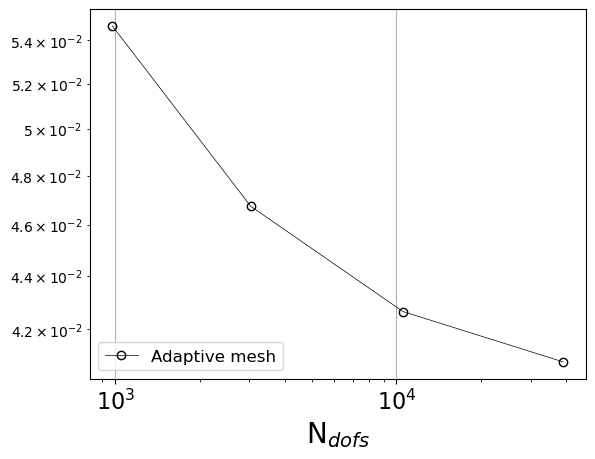

In [8]:
#R_a = np.load('Inductor_adaptive.npy')
R_u = np.load('Inductor_uniform.npy')

numdofs=R_u[:,0]
# numdofs_a = R_a[:,0]
Eerr = R_u[:,2]
# Eerr_a = R_a[:,2]
pos=((2*1e4,7*1e-5),(2.5*1e4,3*1e-5),(5*1e4,5*1e-7),(6*1e4,1e-7))
pos_u=((2*1e3,5*1e-3),(4*1e3,3*1e-3),(1e4,1.5*1e-3),(3*1e3,1e-3))
w = (1.5,1.5,1.5,1.5)
inv = (False,False,False,True)
for i, deg in enumerate((2,3,5,8)):
    numdofs=R_u[:,i*5+0]
    # numdofs_a = R_a[:,i*5+0]
    Eerr = R_u[:,i*5+2]
    # Eerr_a = R_a[:,i*5+2]
    # Eta = R_a[:,i*5+3]

    numdofs=numdofs[numdofs!=0]
    # numdofs_a=numdofs_a[numdofs_a != 0]
    # Eerr_a = Eerr_a[Eerr_a!=0]
    Eerr = Eerr[Eerr!=0]
    # Eta = Eta[Eta!=0]
    
    fig, ax = plt.subplots()
    # plt.loglog(numdofs_a, Eerr_a, 'o-',color='royalblue',linewidth=0.5, markerfacecolor='none')
    # plt.loglog(numdofs_a, Eta, 'x-',color='red',linewidth=0.5, markerfacecolor='none')
    plt.loglog(numdofs, Eerr, 'o-',color='black',linewidth=0.5, markerfacecolor='none')
    plt.grid('True');
    ax.tick_params(axis='both', labelsize=16)
    plt.legend(['Adaptive mesh','Error estimator','Uniform mesh'],loc='lower left',prop={'size': 12})
    plt.xlabel("N$_{dofs}$",size=20)
    draw_loglog_slope(fig,ax,pos[i],w[i],slope=int(deg/2) if deg%2==0 else deg/2,inverted=inv[i], color='black', polygon_kwargs=None, label=True, labelcolor=None, label_kwargs={'fontsize':14}, zorder=None)
    draw_loglog_slope(fig,ax,pos_u[i],w[i],0.33,inverted=inv[i], color='black', polygon_kwargs=None, label=True, labelcolor=None, label_kwargs={'fontsize':14}, zorder=None)

    plt.savefig('LQp'+str(deg)+'n'+str(deg+1)+'H1_cnv.pdf', bbox_inches='tight')
    plt.show()
    